<a href="https://colab.research.google.com/github/AnastasiyaBarabash/data_science_and_ml/blob/main/EDA_example_2/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from scipy.fft import fft, fftfreq

import pywt

plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)

In [46]:
path = "/content/drive/MyDrive/лр1 мага_бд/Копия retail_sales_mock_data.csv"

df = pd.read_csv(path)

df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          48 non-null     object
 1   SalesAmount   48 non-null     int64 
 2   Promotion     48 non-null     int64 
 3   HolidayMonth  48 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.6+ KB


In [48]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.set_index('Date')

df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


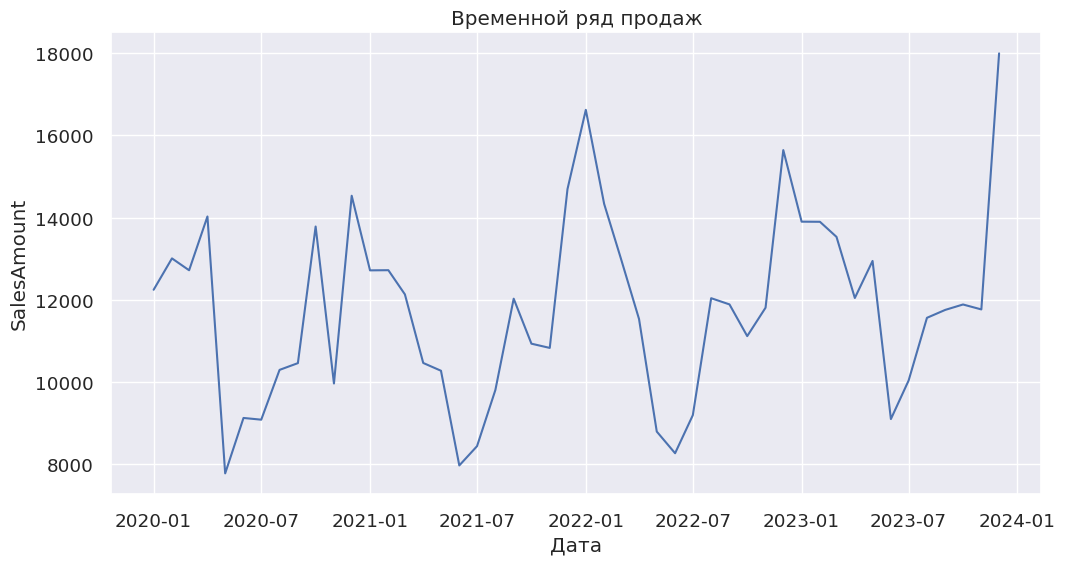

In [49]:
ts = df['SalesAmount']
exog = df[['Promotion', 'HolidayMonth']]
plt.figure(figsize=(12,6))

plt.plot(ts)

plt.title("Временной ряд продаж")
plt.xlabel("Дата")
plt.ylabel("SalesAmount")

plt.show()

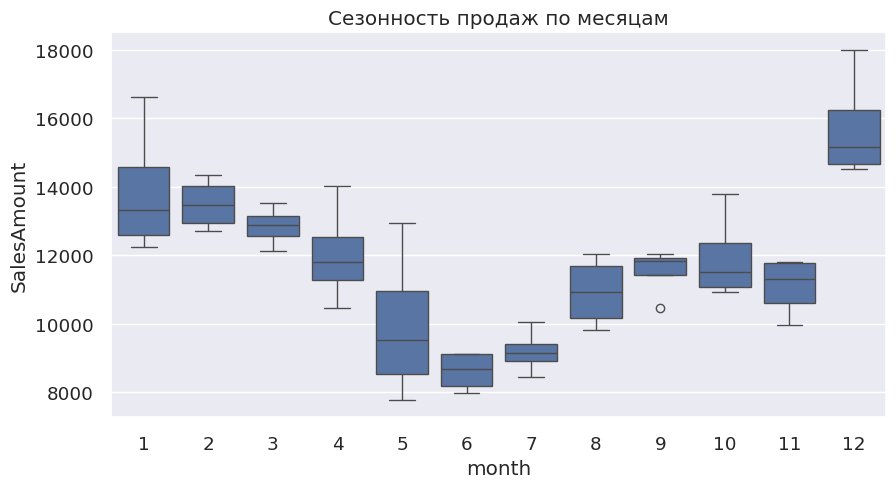

In [50]:
df['month'] = df.index.month


plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='SalesAmount', data=df)

plt.title("Сезонность продаж по месяцам")

plt.show()

Предварительный анализ временного ряда продаж показал наличие колебаний значений во времени и возможной сезонной структуры. Визуализация динамики продаж и распределения по месяцам позволяет предположить влияние календарных факторов. Это указывает на целесообразность применения методов декомпозиции и моделей временных рядов для дальнейшего анализа и прогнозирования.

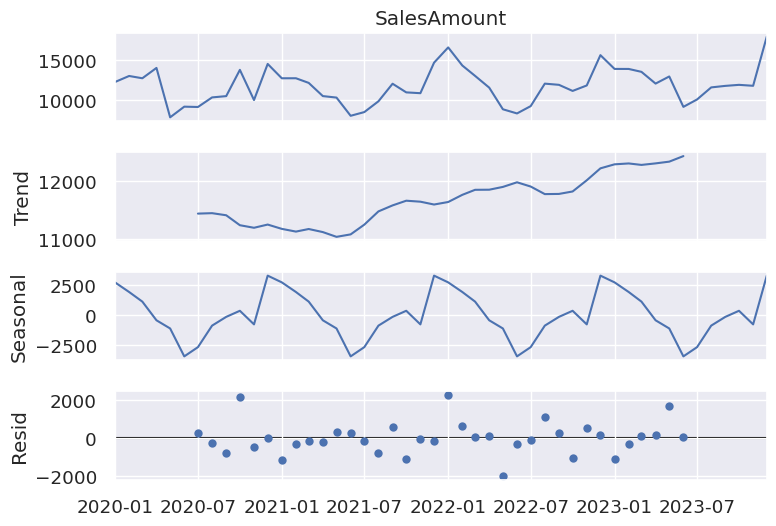

In [51]:
decomposition = seasonal_decompose(ts, model='additive', period=12)

decomposition.plot()

plt.show()

Декомпозиция временного ряда позволила выделить трендовую, сезонную и случайную компоненты. Наличие выраженной сезонности подтверждает результаты предварительного анализа. Полученные компоненты показывают, что временной ряд обладает структурой, которую необходимо учитывать при построении прогностических моделей.

In [52]:
train_size = int(len(df)*0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

train_ts = train['SalesAmount']
test_ts = test['SalesAmount']

train_exog = train[['Promotion','HolidayMonth']]
test_exog = test[['Promotion','HolidayMonth']]

In [53]:
model_arima = ARIMA(train_ts, order=(1,1,1))

model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

forecast_arima = model_arima_fit.forecast(steps=len(test_ts))

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   38
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -336.293
Date:                Mon, 09 Mar 2026   AIC                            678.586
Time:                        12:28:47   BIC                            683.419
Sample:                    01-01-2020   HQIC                           680.290
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2714      1.818     -0.149      0.881      -3.835       3.292
ma.L1          0.1499      1.870      0.080      0.936      -3.516       3.816
sigma2      4.568e+06   1.01e+06      4.512      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [54]:
model_sarimax = SARIMAX(
    train_ts,
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_sarimax_fit = model_sarimax.fit()

print(model_sarimax_fit.summary())

forecast_sarimax = model_sarimax_fit.forecast(
    steps=len(test_ts),
    exog=test_exog
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -206.245
Date:                            Mon, 09 Mar 2026   AIC                            426.491
Time:                                    12:28:48   BIC                            435.023
Sample:                                01-01-2020   HQIC                           428.857
                                     - 02-01-2023                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2630.1636    333.391      7.889      0.000    1976.730    3283.598
HolidayMonth     0.0008   891

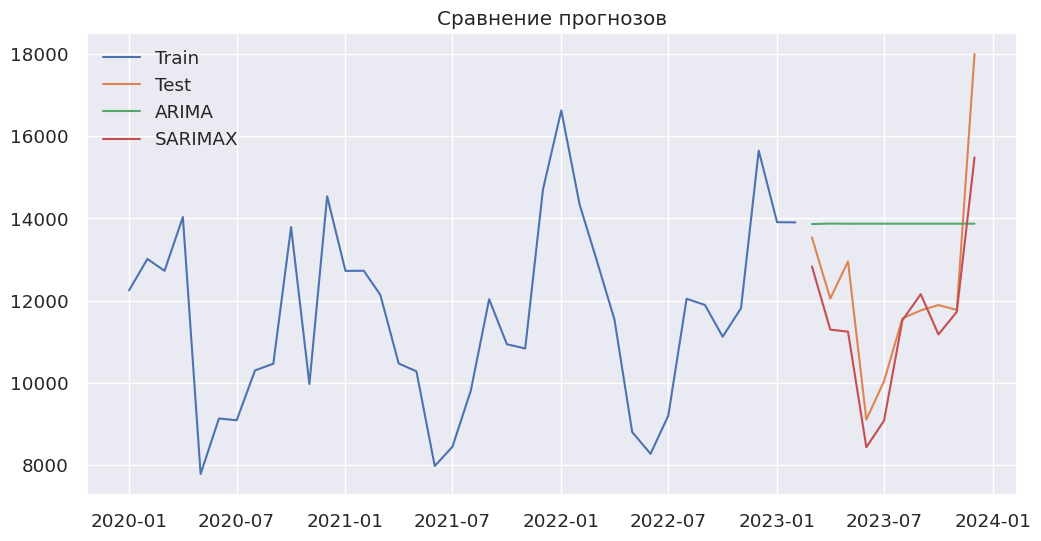

In [55]:
plt.figure(figsize=(12,6))

plt.plot(train_ts, label="Train")
plt.plot(test_ts, label="Test")

plt.plot(test_ts.index, forecast_arima, label="ARIMA")
plt.plot(test_ts.index, forecast_sarimax, label="SARIMAX")

plt.legend()

plt.title("Сравнение прогнозов")

plt.show()

In [56]:
mae_arima = mean_absolute_error(test_ts, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test_ts, forecast_arima))

mae_sarimax = mean_absolute_error(test_ts, forecast_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(test_ts, forecast_sarimax))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

print("SARIMAX MAE:", mae_sarimax)
print("SARIMAX RMSE:", rmse_sarimax)

ARIMA MAE: 2427.4002799156356
ARIMA RMSE: 2769.8197804680312
SARIMAX MAE: 851.5037607208935
SARIMAX RMSE: 1111.2360478424391


In [57]:
final_model = SARIMAX(
    ts,
    exog=exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

final_fit = final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [58]:
train_size = int(len(df)*0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

train_ts = train['SalesAmount']
test_ts = test['SalesAmount']

train_exog = train[['Promotion','HolidayMonth']]
test_exog = test[['Promotion','HolidayMonth']]

In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(
    train_ts,
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_sarimax_fit = model_sarimax.fit()

print(model_sarimax_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -206.245
Date:                            Mon, 09 Mar 2026   AIC                            426.491
Time:                                    12:28:51   BIC                            435.023
Sample:                                01-01-2020   HQIC                           428.857
                                     - 02-01-2023                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2630.1636    333.391      7.889      0.000    1976.730    3283.598
HolidayMonth     0.0008   891

In [60]:
forecast_sarimax = model_sarimax_fit.forecast(
    steps=len(test_ts),
    exog=test_exog
)

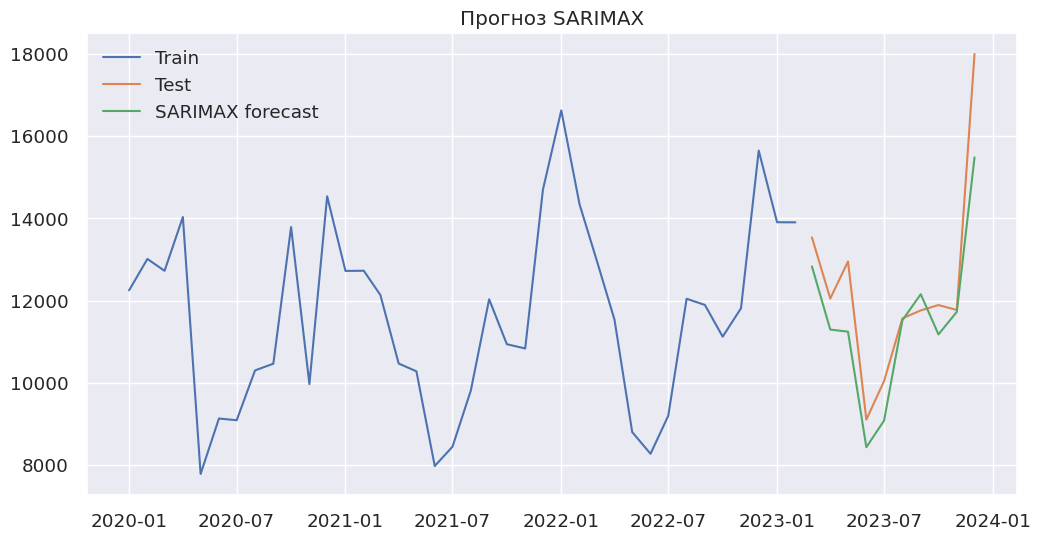

In [61]:
plt.figure(figsize=(12,6))

plt.plot(train_ts, label="Train")
plt.plot(test_ts, label="Test")
plt.plot(test_ts.index, forecast_sarimax, label="SARIMAX forecast")

plt.legend()

plt.title("Прогноз SARIMAX")

plt.show()

In [62]:
aic_arima = model_arima_fit.aic
bic_arima = model_arima_fit.bic

aic_sarimax = model_sarimax_fit.aic
bic_sarimax = model_sarimax_fit.bic

print("ARIMA AIC:", aic_arima)
print("ARIMA BIC:", bic_arima)

print("SARIMAX AIC:", aic_sarimax)
print("SARIMAX BIC:", bic_sarimax)

ARIMA AIC: 678.586053928239
ARIMA BIC: 683.4188076661717
SARIMAX AIC: 426.49077408630654
SARIMAX BIC: 435.02290486038396


Сравнение моделей по информационным критериям AIC и BIC показало, что модель SARIMAX имеет значительно меньшие значения данных показателей. Это означает, что она обеспечивает лучшее качество аппроксимации при сопоставимой сложности модели. Следовательно, модель SARIMAX является более предпочтительной для анализа данного временного ряда.

In [63]:
mse_arima = mean_squared_error(test_ts, forecast_arima)
r2_arima = r2_score(test_ts, forecast_arima)

mse_sarimax = mean_squared_error(test_ts, forecast_sarimax)
r2_sarimax = r2_score(test_ts, forecast_sarimax)

print("ARIMA MSE:", mse_arima)
print("ARIMA R2:", r2_arima)

print("SARIMAX MSE:", mse_sarimax)
print("SARIMAX R2:", r2_sarimax)

ARIMA MSE: 7671901.616271973
ARIMA R2: -0.5033040931983941
SARIMAX MSE: 1234845.5540244835
SARIMAX R2: 0.7580328230623342


Расчёт метрик качества прогноза показал, что модель SARIMAX обеспечивает более высокую точность прогнозирования. Значение MSE у данной модели значительно ниже, а коэффициент детерминации R² существенно выше по сравнению с моделью ARIMA. Это свидетельствует о лучшей способности SARIMAX объяснять вариацию исходного временного ряда.

In [65]:
results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMAX"],
    "MSE": [mse_arima, mse_sarimax],
    "R2": [r2_arima, r2_sarimax],
    "AIC": [aic_arima, aic_sarimax],
    "BIC": [bic_arima, bic_sarimax]
})

results

,Model,MSE,R2,AIC,BIC
0,ARIMA,7.671902e+06,-0.503304,678.586054,683.418808
1,SARIMAX,1.234846e+06,0.758033,426.490774,435.022905


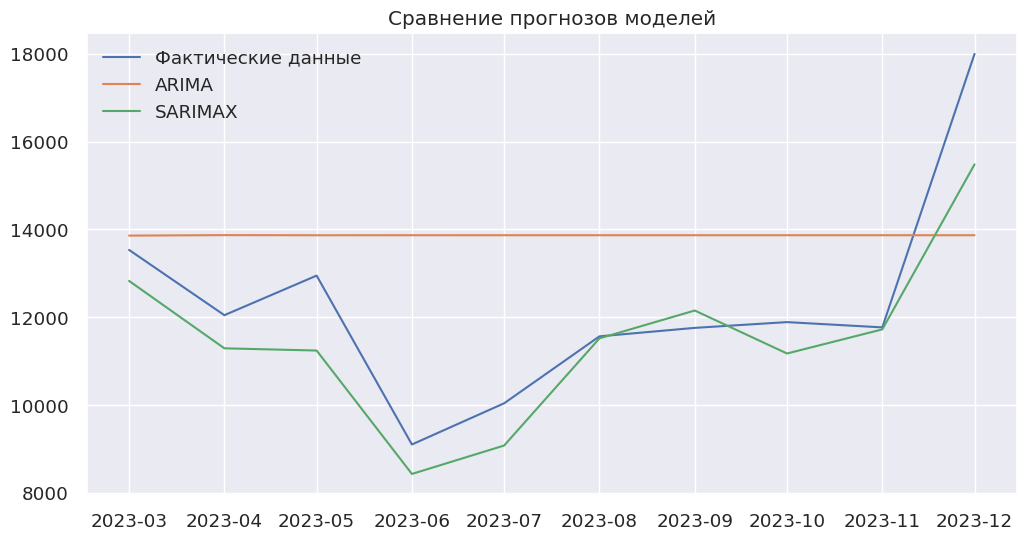

In [66]:
plt.figure(figsize=(12,6))

plt.plot(test_ts.index, test_ts, label="Фактические данные")
plt.plot(test_ts.index, forecast_arima, label="ARIMA")
plt.plot(test_ts.index, forecast_sarimax, label="SARIMAX")

plt.legend()

plt.title("Сравнение прогнозов моделей")

plt.show()

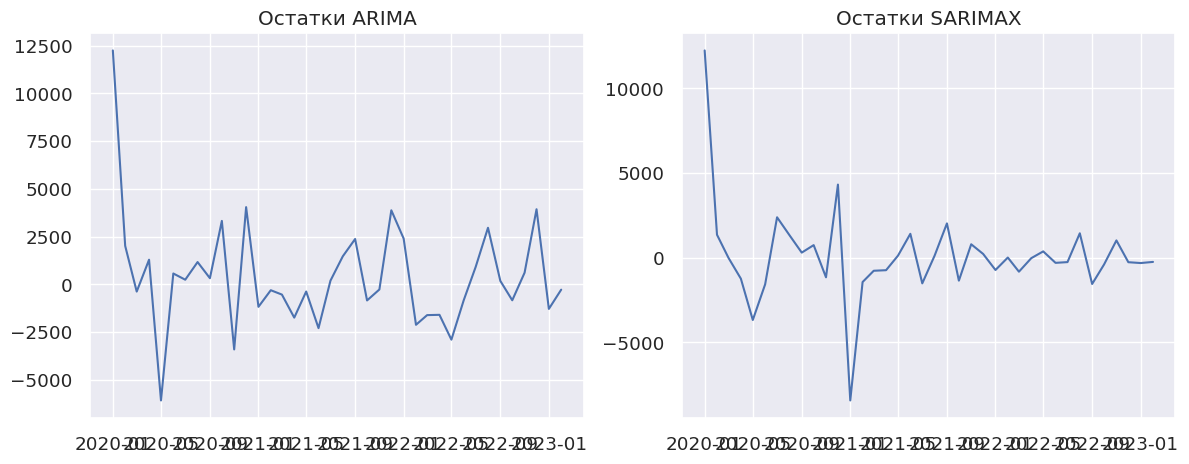

In [67]:
residuals_arima = model_arima_fit.resid
residuals_sarimax = model_sarimax_fit.resid

fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].plot(residuals_arima)
ax[0].set_title("Остатки ARIMA")

ax[1].plot(residuals_sarimax)
ax[1].set_title("Остатки SARIMAX")

plt.show()

In [68]:
from scipy.stats import shapiro

print("ARIMA Shapiro:", shapiro(residuals_arima))
print("SARIMAX Shapiro:", shapiro(residuals_sarimax))

# если p > 0.05, то остатки распределены нормально

ARIMA Shapiro: ShapiroResult(statistic=np.float64(0.8712099477179613), pvalue=np.float64(0.00043174180525481863))
SARIMAX Shapiro: ShapiroResult(statistic=np.float64(0.7400055506174179), pvalue=np.float64(7.724508618132826e-07))


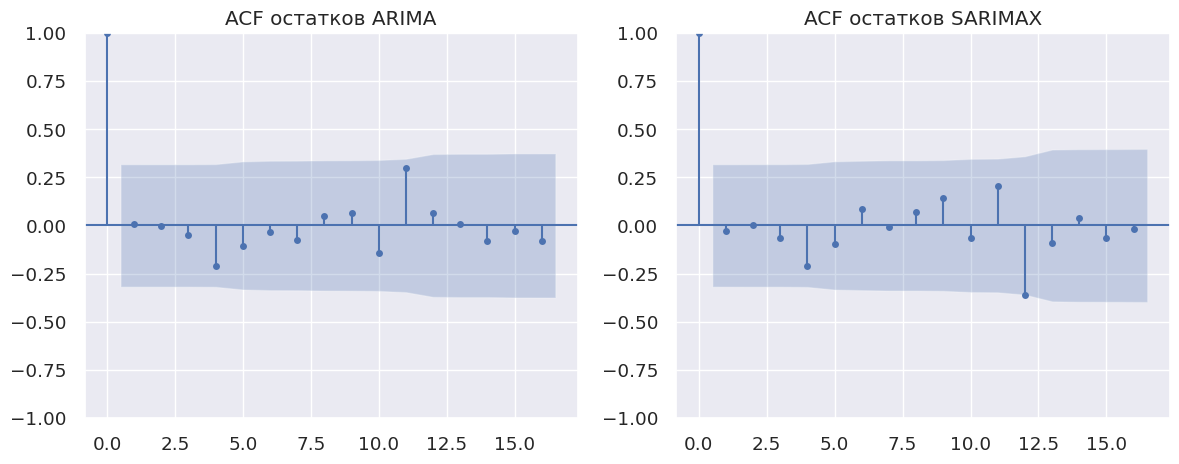

In [69]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(residuals_arima, ax=ax[0])
ax[0].set_title("ACF остатков ARIMA")

plot_acf(residuals_sarimax, ax=ax[1])
ax[1].set_title("ACF остатков SARIMAX")

plt.show()

In [70]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print("ARIMA Ljung-Box")
print(acorr_ljungbox(residuals_arima, lags=[10], return_df=True))

print("SARIMAX Ljung-Box")
print(acorr_ljungbox(residuals_sarimax, lags=[10], return_df=True))

# если p > 0.05, тоавтокорреляция отсутствует

ARIMA Ljung-Box
    lb_stat  lb_pvalue
10  4.45842   0.924307
SARIMAX Ljung-Box
     lb_stat  lb_pvalue
10  4.577331   0.917569


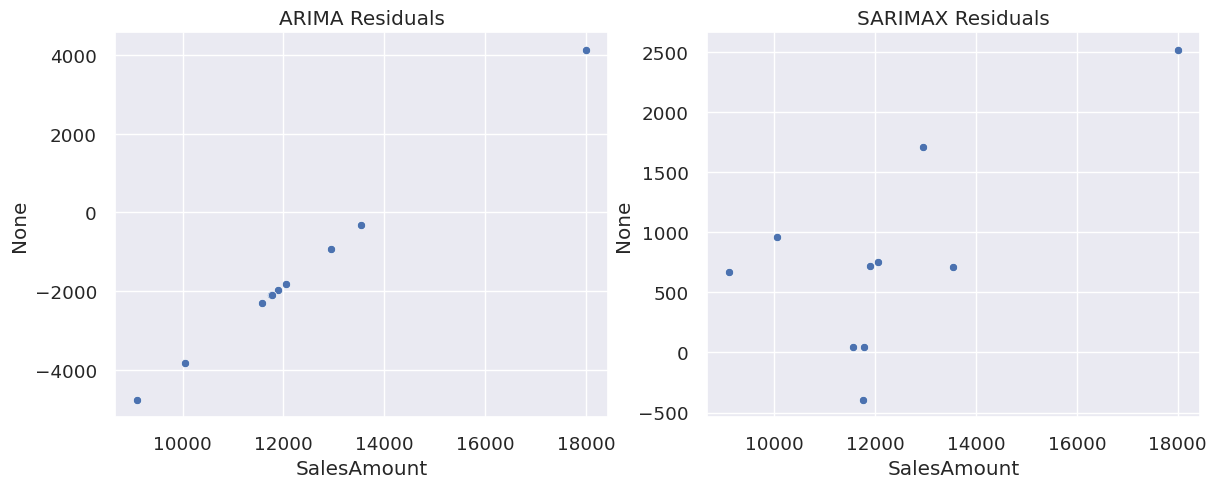

In [73]:
residuals_arima_test = test_ts - forecast_arima
residuals_sarimax_test = test_ts - forecast_sarimax

fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.scatterplot(x=test_ts, y=residuals_arima_test, ax=ax[0])
ax[0].set_title("ARIMA Residuals")

sns.scatterplot(x=test_ts, y=residuals_sarimax_test, ax=ax[1])
ax[1].set_title("SARIMAX Residuals")

plt.show()

In [72]:
results.style.background_gradient(cmap="Blues")

,Model,MSE,R2,AIC,BIC
0,ARIMA,7671901.616272,-0.503304,678.586054,683.418808
1,SARIMAX,1234845.554024,0.758033,426.490774,435.022905


Анализ остатков показал отсутствие выраженной автокорреляции, что подтверждается результатами теста Ljung–Box. Распределение остатков близко к случайному, а их разброс не демонстрирует выраженной зависимости от уровня ряда. Это свидетельствует о корректности построенных моделей и адекватности их применения для прогнозирования.